<a href="https://colab.research.google.com/github/vineetsalar88/ResearchPaper2/blob/master/March2026/13marchYolo8Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 68.8 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

# load pretrained classification model
model = YOLO("yolov8n-cls.pt")

# train
results = model.train(
    data="/content/drive/MyDrive/ResearchData/DatasetTrainVsTest10march",
    epochs=30,
    imgsz=224,
    batch=32,
    device=0
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/ResearchData/DatasetTrainVsTest10march, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_ma

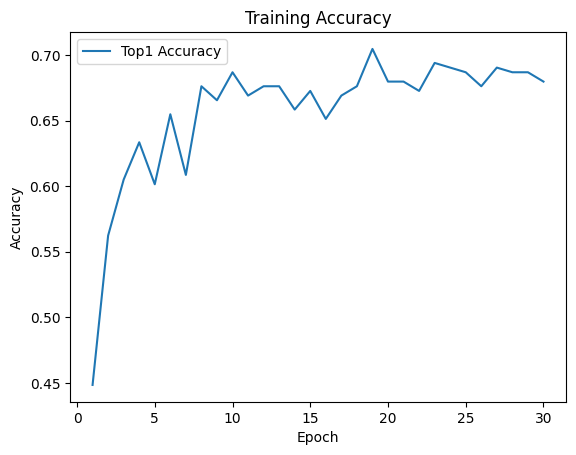

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("/content/runs/classify/train3/results.csv")

plt.plot(df['epoch'], df['metrics/accuracy_top1'], label="Top1 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.legend()
plt.show()

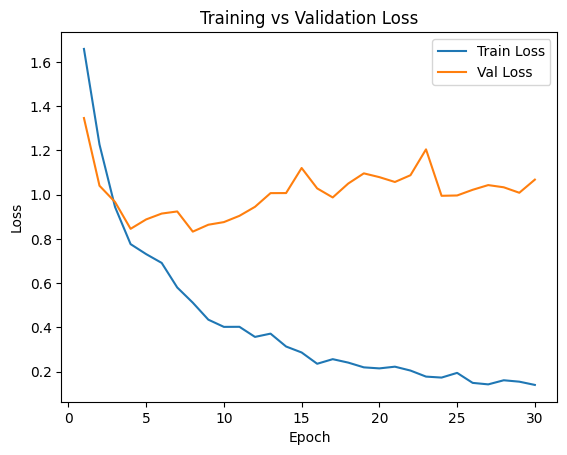

In [ ]:
plt.figure()
plt.plot(df['epoch'], df['train/loss'], label="Train Loss")
plt.plot(df['epoch'], df['val/loss'], label="Val Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import torch
plt.savefig("/content/runs/classify/train3/confusion_matrix_normalized.png", dpi=300)
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
for label, class_name in enumerate(class_names):

    class_folder = os.path.join(val_path, class_name)

    for img in os.listdir(class_folder):

        img_path = os.path.join(class_folder, img)

        result = model(img_path)

        pred = result[0].probs.top1

        y_pred.append(pred)
        y_true.append(label)
# create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# plot
plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("/content/runs/classify/train3/confusion_matrix_normalized.png", dpi=300)
plt.show()



NameError: name 'class_names' is not defined